Imports

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

Loading the dataset

In [2]:
df = pd.read_csv(
    "/run/media/aditya-anurag/New Volume/Self/Personal/Project/Credit Risk Intelligence & Default Prediction/data/processed/feature_engineered_loan_data.csv",
    low_memory=False
)

print(df.shape)

(1303607, 142)


Creating Modelling Copy

In [3]:
model_df = df.copy()

Removing remaining non-modelling columns

In [ ]:
# -----------------------------------------
# Drop Leakage / Non-Predictive Columns
# -----------------------------------------

drop_cols = [

    # Target leakage / post-loan servicing
    'loan_status',
    'last_pymnt_d',
    'last_pymnt_amnt',
    'next_pymnt_d',
    'last_credit_pull_d',

    # Recovery / collection leakage
    'recoveries',
    'collection_recovery_fee',
    'total_rec_prncp',
    'total_rec_int',
    'total_rec_late_fee',
    'total_pymnt',
    'total_pymnt_inv',
    'out_prncp',
    'out_prncp_inv',

    # Settlement leakage
    'debt_settlement_flag',
    'debt_settlement_flag_date',
    'settlement_status',
    'settlement_date',
    'settlement_amount',
    'settlement_percentage',
    'settlement_term',

    # Identifiers / metadata
    'id',
    'member_id',
    'url',

    # High-cardinality noisy text
    'emp_title',

    # Raw date columns
    'issue_d',
    'earliest_cr_line'

]

# Drop only existing columns safely
model_df = model_df.drop(
    columns=[
        col for col in drop_cols
        if col in model_df.columns
    ],
    errors='ignore'
)

print("Updated Shape:", model_df.shape)

Updated Shape: (1303607, 131)


Handling infinite values

In [108]:
model_df = model_df.replace(
    [np.inf, -np.inf],
    np.nan
)

Filling remaining missing values

In [109]:
for col in model_df.columns:

    try:
        model_df[col] = pd.to_numeric(
            model_df[col]
        )

    except:
        pass

In [110]:
for col in model_df.columns:

    # Handle categorical/object columns
    if model_df[col].dtype == 'object':

        model_df[col] = model_df[col].fillna('unknown')

    # Handle numeric columns
    else:

        if pd.api.types.is_numeric_dtype(model_df[col]):

            model_df[col] = model_df[col].fillna(
                model_df[col].median()
            )

Encode Categorical Variables

In [111]:
cat_cols = model_df.select_dtypes(
    include='object'
).columns

cat_cols

Index([], dtype='str')

In [112]:
label_encoders = {}

for col in cat_cols:

    le = LabelEncoder()

    model_df[col] = le.fit_transform(
        model_df[col].astype(str)
    )

    label_encoders[col] = le

Define Features & Target

In [113]:
X = model_df.drop(
    columns=['target_default']
)

y = model_df['target_default']

Train-Test Split

In [114]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1042885, 130)
(260722, 130)


Scale Numerical Features

In [115]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Baseline Model

In [116]:
baseline_prediction = np.zeros_like(y_test)

print(
    "Baseline Accuracy:",
    accuracy_score(
        y_test,
        baseline_prediction
    )
)

Baseline Accuracy: 0.799284295149623


Logistic Regression Model


In [117]:
log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

log_model.fit(
    X_train_scaled,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

Predictions

In [118]:
log_preds = log_model.predict(
    X_test_scaled
)

log_probs = log_model.predict_proba(
    X_test_scaled
)[:,1]

Logistic Regression Evaluation

In [119]:
print(
    classification_report(
        y_test,
        log_preds
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        log_probs
    )
)

              precision    recall  f1-score   support

           0       0.88      0.67      0.76    208391
           1       0.33      0.65      0.44     52331

    accuracy                           0.67    260722
   macro avg       0.61      0.66      0.60    260722
weighted avg       0.77      0.67      0.70    260722

ROC-AUC: 0.7198731259181573


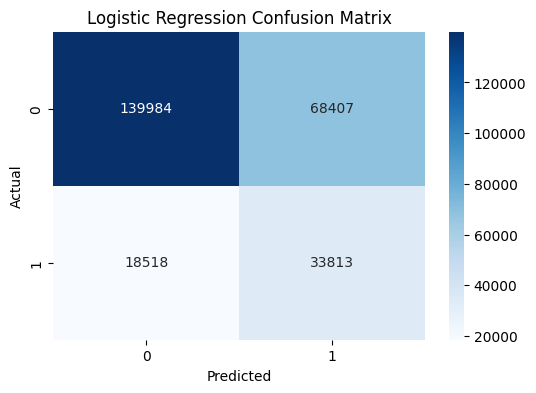

In [120]:
#Confusion Matrix
cm = confusion_matrix(
    y_test,
    log_preds
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

Random Forest Model

In [121]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [122]:
#Predictions
rf_preds = rf_model.predict(X_test)

rf_probs = rf_model.predict_proba(
    X_test
)[:,1]

In [123]:
#Evaluation
print(
    classification_report(
        y_test,
        rf_preds
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        rf_probs
    )
)

              precision    recall  f1-score   support

           0       0.89      0.64      0.74    208391
           1       0.32      0.68      0.43     52331

    accuracy                           0.64    260722
   macro avg       0.60      0.66      0.59    260722
weighted avg       0.77      0.64      0.68    260722

ROC-AUC: 0.7195825710262531


XGBoost Model

In [124]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [125]:
#Predictions
xgb_preds = xgb_model.predict(
    X_test
)

xgb_probs = xgb_model.predict_proba(
    X_test
)[:,1]

In [126]:
#Evaluation
print(
    classification_report(
        y_test,
        xgb_preds
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        xgb_probs
    )
)

              precision    recall  f1-score   support

           0       0.81      0.98      0.89    208391
           1       0.61      0.11      0.18     52331

    accuracy                           0.81    260722
   macro avg       0.71      0.55      0.54    260722
weighted avg       0.77      0.81      0.75    260722

ROC-AUC: 0.7333943827030454


ROC Curve Comparison

In [127]:
log_fpr, log_tpr, _ = roc_curve(
    y_test,
    log_probs
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_probs
)

xgb_fpr, xgb_tpr, _ = roc_curve(
    y_test,
    xgb_probs
)

Plot

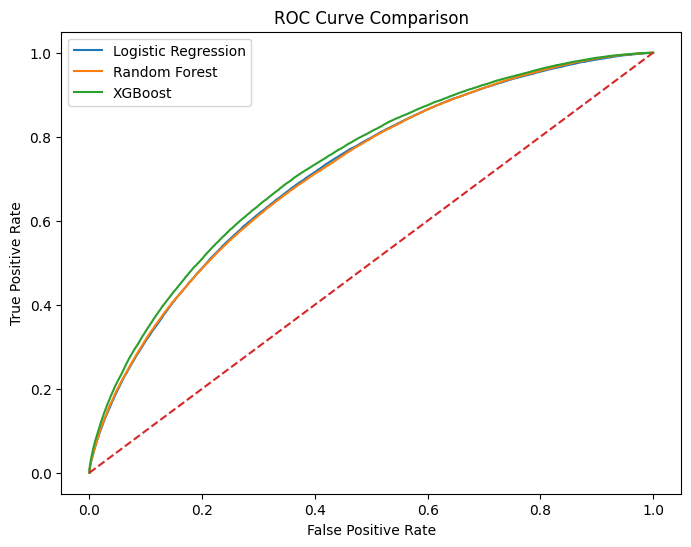

In [128]:
plt.figure(figsize=(8,6))

plt.plot(log_fpr, log_tpr, label='Logistic Regression')

plt.plot(rf_fpr, rf_tpr, label='Random Forest')

plt.plot(xgb_fpr, xgb_tpr, label='XGBoost')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve Comparison')

plt.legend()

plt.show()

Feature Importance

In [129]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='importance',
    ascending=False
)

feature_importance.head(20)

,feature,importance
7,sub_grade,0.209237
6,grade,0.158195
4,int_rate,0.154966
3,term,0.078853
118,income_to_loan_ratio,0.032125
128,installment_to_income,0.024509
18,dti,0.023670
54,acc_open_past_24mths,0.019097
87,tot_hi_cred_lim,0.015622
55,avg_cur_bal,0.013101


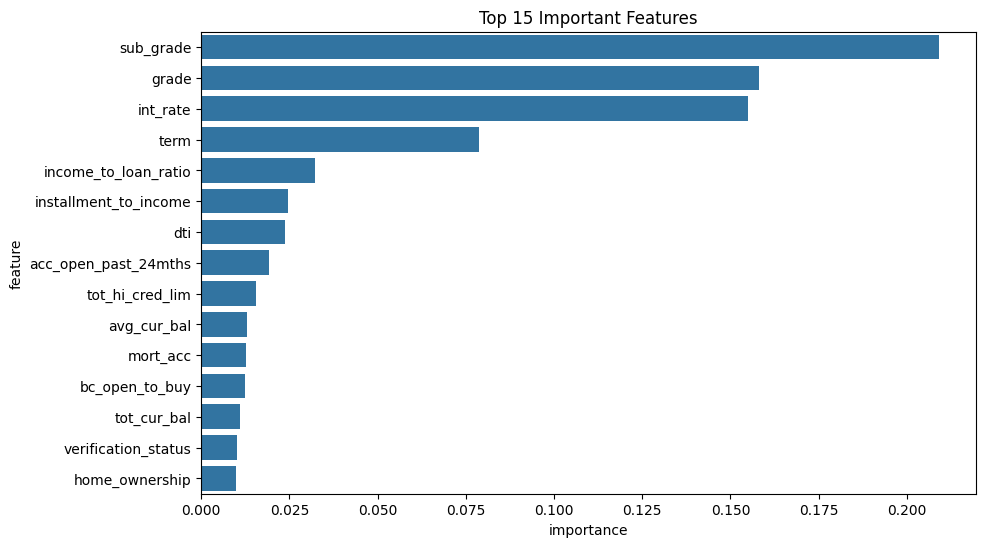

In [130]:
#Visualization
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(15),
    x='importance',
    y='feature'
)

plt.title('Top 15 Important Features')

plt.show()

Business Risk Threshold

In [131]:
#Creating Risk Bands
risk_scores = pd.DataFrame({
    'actual': y_test,
    'probability_default': xgb_probs
})

In [132]:
#Creating risk categories
risk_scores['risk_band'] = pd.cut(
    risk_scores['probability_default'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1],
    labels=[
        'Very Low Risk',
        'Low Risk',
        'Medium Risk',
        'High Risk',
        'Very High Risk'
    ]
)

Risk Band Analysis

In [133]:
risk_scores.groupby(
    'risk_band'
)['actual'].mean() * 100

risk_band
Very Low Risk     10.782100
Low Risk          28.050519
Medium Risk       48.016605
High Risk         68.668076
Very High Risk    93.679458
Name: actual, dtype: float64

Saving the models

In [134]:
import joblib

In [135]:
joblib.dump(
    log_model,
    "/run/media/aditya-anurag/New Volume/Self/Personal/Project/Credit Risk Intelligence & Default Prediction/outputs/models/logistic_model.pkl"
)

joblib.dump(
    rf_model,
    "/run/media/aditya-anurag/New Volume/Self/Personal/Project/Credit Risk Intelligence & Default Prediction/outputs/models/random_forest_model.pkl"
)

joblib.dump(
    xgb_model,
    "/run/media/aditya-anurag/New Volume/Self/Personal/Project/Credit Risk Intelligence & Default Prediction/outputs/models/xgboost_model.pkl"
)

['/run/media/aditya-anurag/New Volume/Self/Personal/Project/Credit Risk Intelligence & Default Prediction/outputs/models/xgboost_model.pkl']

Saving Risk Scores

In [136]:
risk_scores.to_csv(
    "/run/media/aditya-anurag/New Volume/Self/Personal/Project/Credit Risk Intelligence & Default Prediction/outputs/predictions/risk_scores.csv",
    index=False
)

# Business Conclusion

## Executive Summary

This project developed an end-to-end credit risk analytics and default prediction platform using historical LendingClub consumer loan data.

The objective was to:
- identify borrower-level default risk,
- engineer financially meaningful risk features,
- build predictive default models,
- and generate actionable lending risk insights.

The analysis demonstrated that borrower financial behavior, debt burden, repayment capacity, and internal credit grading contain meaningful predictive signals for loan default.

---

# Model Performance Summary

Three predictive models were evaluated:
- Logistic Regression
- Random Forest
- XGBoost

Among the evaluated approaches:
- XGBoost achieved the strongest overall discriminatory performance with a ROC-AUC score of approximately 0.73.
- Logistic Regression and Random Forest produced comparable performance with ROC-AUC values near 0.72.

The ROC curve analysis showed that all models performed materially better than random classification, indicating the presence of meaningful borrower risk patterns within the dataset.

---

# Key Risk Drivers Identified

The most influential borrower risk indicators included:

- Loan Grade
- Sub Grade
- Interest Rate
- Loan Term
- Debt-to-Income Ratio (DTI)
- Income-to-Loan Ratio
- Installment-to-Income Ratio
- Credit Exposure Metrics

These findings indicate that:
- borrower leverage,
- repayment burden,
- and LendingClub’s internal grading system

are strongly associated with realized default outcomes.

---

# Feature Engineering Insights

Custom engineered variables such as:
- income_to_loan_ratio
- installment_to_income
- credit_exposure_score

provided meaningful predictive contribution.

This demonstrates that repayment capacity and borrower financial stress are critical drivers of default probability.

The feature engineering process significantly improved the project’s ability to represent borrower-level financial risk behavior.

---

# Risk Segmentation Analysis

The generated probability-based risk bands successfully separated borrowers into progressively riskier categories.

Observed default rates by risk segment:

| Risk Band | Observed Default Rate |
|---|---|
| Very Low Risk | ~11% |
| Low Risk | ~28% |
| Medium Risk | ~48% |
| High Risk | ~69% |
| Very High Risk | ~94% |

This demonstrates strong borrower risk stratification capability.

The scoring framework can support:
- credit approval prioritization,
- portfolio monitoring,
- risk-based pricing,
- and underwriting review workflows.

---

# Business Recommendations

## 1. Tighten Lending for High-Risk Borrowers

Borrowers with:
- weaker grades/subgrades,
- elevated interest rates,
- and higher repayment burden

demonstrated significantly higher default probability.

Potential actions:
- stricter approval thresholds,
- enhanced verification,
- lower loan limits,
- or risk-adjusted pricing.

---

## 2. Monitor Debt Burden Metrics

Variables such as:
- DTI,
- installment burden,
- and utilization-related features

showed strong association with repayment distress.

Potential actions:
- implement DTI-based controls,
- strengthen affordability checks,
- and monitor leveraged borrowers more aggressively.

---

## 3. Incorporate Repayment Capacity Indicators

Engineered affordability metrics proved highly informative.

Recommendation:
- integrate repayment-capacity features directly into credit policy and borrower screening systems.

---

## 4. Use Probability-Based Risk Bands Operationally

The generated risk bands can support:
- portfolio segmentation,
- collection prioritization,
- early warning monitoring,
- and manual underwriting escalation.

---

# Final Outcome

This project successfully demonstrates:
- structured credit risk analytics,
- end-to-end machine learning pipeline development,
- financial feature engineering,
- predictive default modeling,
- and business-oriented borrower risk segmentation.

The project reflects practical application of:
- data science,
- financial analytics,
- and decision-support modeling
within a consumer lending environment.